# Stage A — Per-sensor validation against AERONET

Companion to `validate_heldout.ipynb` (which validates the *merged* product) and
to `validate_intercomparison.ipynb` §8.1.4 (which evaluates B1 best-single-sensor
post-correction).  Here we match every **raw** per-sensor `AOD_<sensor>` from
`GRIDDED_DIR` (before the §7.4 soft calibration and the §7.5 stratum-aware merge)
against AERONET ±30 min and report per-sensor performance.

Sensors (separate L2 and L3 Himawari channels, since the L2/L3 collapse happens
only at the merge step):

* `AOD_himawari_l2`
* `AOD_himawari_l3`
* `AOD_modis_maiac`
* `AOD_viirs_snpp`
* `AOD_viirs_noaa20`

Strata: site (`NGHIA_DO` = north, `Bac_Lieu` = south, `ALL`) × season
(`dry` Oct–Apr, `wet` May–Sep, `ALL`).  Metrics reported per stratum:

| symbol | meaning |
|---|---|
| `N` | matched pairs |
| `R` | Pearson correlation |
| `R²` | coefficient of determination (`1 − SS_res/SS_tot` vs AERONET, mirrors the §8.1.1 convention) |
| `RMSE` | root-mean-square error against AERONET |
| `MBE` | mean bias error = `mean(sat − AERONET)` |
| `%EE` | fraction within MODIS DT envelope `±(0.05 + 0.15·AOD_AERONET)` |
| `slope` / `intercept` | OLS line `sat = slope · AERONET + intercept` |


## 0. Setup

In [1]:
from datetime import date
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from config import (
    AERONET_SITES, TEST_START, TEST_END, DRY_MONTHS,
    COLLOCATE_DIR,
)
from validate import compute_metrics

start, end = TEST_START, TEST_END
print(f'Validation window: {start} → {end}')
print(f'AERONET sites:    {list(AERONET_SITES)}')
print(f'Collocate dir:    {COLLOCATE_DIR}')


Validation window: 2025-01-01 → 2026-04-30
AERONET sites:    ['NGHIA_DO', 'Bac_Lieu']
Collocate dir:    /home/slow_data/Air_Quality/Stage_A/collocated


## 1. Build the per-sensor matched-pair table

Loads the per-sensor matched pairs directly from `COLLOCATE_DIR/{sensor}_{site}.csv`,
the product of `extract_satellite.extract_site` + `collocate.match_site`. Each row
is one satellite snapshot at a station, paired with the AERONET ±`LEO_WINDOW_MIN`/
`MODIS_WINDOW_MIN` time-window mean, sampled at the station's 0.05° cell with the
tiered 1×1 → 3×3 → 5×5 fallback and the `box_std` heterogeneity gate.

Validates **raw / pre-correction** sensor AOD against AERONET; no §7.4 soft cal
or §7.5 fusion is applied. The `satellite_aod` column from the CSV is renamed
to `sat_aod` so downstream plotting cells see the same schema.


In [2]:
def load_collocate_pairs(
    start: date,
    end:   date,
    collocate_dir: Path = Path(COLLOCATE_DIR),
) -> pd.DataFrame:
    """Concatenate per-(sensor, site) collocate CSVs, filter by date window.

    The CSVs already carry the production pairing (tiered cell fallback +
    time window) — no re-pairing here.
    """
    csvs = sorted(Path(collocate_dir).glob('*.csv'))
    if not csvs:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(p) for p in csvs], ignore_index=True)
    df = df[df['site'].isin(AERONET_SITES)].copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df[(df['date'] >= pd.Timestamp(start)) &
            (df['date'] <= pd.Timestamp(end))].copy()
    df = df.rename(columns={'satellite_aod': 'sat_aod'})
    return df


pairs = load_collocate_pairs(start, end)
if pairs.empty:
    print(f'No CSVs found in {COLLOCATE_DIR} — run `run_collocate.py extract && match` first.')
else:
    print(f'{len(pairs):,} per-sensor matched pairs over [{start}, {end}]')
    print()
    print('Pairs per (sensor, site):')
    print(pairs.groupby(['sensor', 'site']).size().unstack(fill_value=0))


1,521 per-sensor matched pairs over [2025-01-01, 2026-04-30]

Pairs per (sensor, site):
site          Bac_Lieu  NGHIA_DO
sensor                          
himawari_l2        146       434
himawari_l3         22       168
modis_maiac        221       214
viirs_noaa20        59       102
viirs_snpp          59        96


## 2. OLS slope / intercept via `scipy.stats.linregress`

`scipy.stats.linregress(x, y)` returns a `LinregressResult` with `slope`,
`intercept`, `rvalue` (= Pearson R), `pvalue`, `stderr`, and `intercept_stderr`
in one call — no need to call `LinearRegression().fit(...).coef_` /
`.intercept_` separately and then recompute R on the side.

Convention: AERONET on the x-axis, satellite on the y-axis, so an unbiased
sensor reads `slope ≈ 1`, `intercept ≈ 0`.  OLS is asymmetric in `x`/`y`
— it assumes AERONET is error-free and minimises residuals only in the
satellite direction; we accept that as the standard reading.

In [3]:
def ols_regression(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """OLS slope and intercept of `y` on `x` via `scipy.stats.linregress`.

    `x` is AERONET, `y` is the satellite retrieval.  Both 1-D and already
    filtered to finite values.
    """
    res = stats.linregress(x, y)
    return float(res.slope), float(res.intercept)


# Smoke test — a synthetic unbiased sensor should give slope ≈ 1, intercept ≈ 0.
_rng = np.random.default_rng(0)
_x   = _rng.uniform(0.1, 1.5, size=500)
_y   = _x + _rng.normal(0, 0.05, size=500)
_s, _i = ols_regression(_x, _y)
print(f'Smoke test: slope={_s:.3f}, intercept={_i:.3f}')
assert 0.9 < _s < 1.1 and abs(_i) < 0.05, 'Slope/intercept outside sanity bounds'
print('  PASS')


Smoke test: slope=1.002, intercept=-0.005
  PASS


## 3. Stratified metric panel

`compute_metrics` from [validate.py](validate.py) gives N, R, R², RMSE, MAE, Bias
(= MBE), and %EE; we extend each row with `slope` and `intercept` from the
OLS helper above.

Strata: `(site, season)` with `'ALL'` aggregating that axis.  Rows with
fewer than 10 pairs are reported but their R / R² / slope columns are NaN
(`compute_metrics` already enforces that floor).

In [4]:
def metrics_with_ols(sub: pd.DataFrame, label: str) -> dict:
    """compute_metrics + OLS slope/intercept on one stratum."""
    sat = sub['sat_aod'].to_numpy(dtype=np.float64)
    aer = sub['aeronet_aod'].to_numpy(dtype=np.float64)
    m   = compute_metrics(sat, aer, label=label)
    # Re-mask exactly as compute_metrics does (so slope/intercept align with N)
    mask = np.isfinite(sat) & np.isfinite(aer)
    if mask.sum() >= 10:
        slope, intercept = ols_regression(aer[mask], sat[mask])
    else:
        slope, intercept = (np.nan, np.nan)
    m['slope']     = slope
    m['intercept'] = intercept
    m['MBE']       = m.pop('Bias')   # rename to the symbol used in the spec
    return m


def stratified_persensor(pairs: pd.DataFrame) -> pd.DataFrame:
    """One row per (sensor, site, season) including site=ALL and season=ALL."""
    if pairs.empty:
        return pd.DataFrame()

    sites_iter   = list(AERONET_SITES.keys()) + ['ALL']
    seasons_iter = ['dry', 'wet', 'ALL']

    rows: list[dict] = []
    for sensor, sgrp in pairs.groupby('sensor'):
        for site in sites_iter:
            sub_site = sgrp if site == 'ALL' else sgrp[sgrp['site'] == site]
            if sub_site.empty:
                continue
            for season in seasons_iter:
                sub = sub_site if season == 'ALL' else sub_site[sub_site['season'] == season]
                if sub.empty:
                    continue
                m = metrics_with_ols(
                    sub, label=f'{sensor} | {site} | {season}'
                )
                m.update({'sensor': sensor, 'site': site, 'season': season})
                rows.append(m)
    return pd.DataFrame(rows)


if not pairs.empty:
    panel = stratified_persensor(pairs)
    cols  = ['sensor', 'site', 'season', 'N', 'R', 'R2', 'RMSE',
             'MBE', 'pct_EE', 'slope', 'intercept']
    panel = panel[cols].sort_values(['sensor', 'site', 'season']).reset_index(drop=True)
    with pd.option_context('display.max_rows', None):
        print(panel.round(3).to_string(index=False))
else:
    panel = pd.DataFrame()


      sensor     site season   N     R      R2  RMSE    MBE  pct_EE  slope  intercept
 himawari_l2      ALL    ALL 580 0.836   0.641 0.357 -0.112  41.724  0.573      0.201
 himawari_l2      ALL    dry 541 0.837   0.641 0.365 -0.117  41.590  0.572      0.205
 himawari_l2      ALL    wet  39 0.531   0.199 0.213 -0.049  43.590  0.389      0.248
 himawari_l2 Bac_Lieu    ALL 146 0.294  -1.912 0.265  0.121  50.685  0.433      0.313
 himawari_l2 Bac_Lieu    dry 140 0.274  -2.004 0.269  0.121  51.429  0.408      0.326
 himawari_l2 Bac_Lieu    wet   6   NaN     NaN   NaN    NaN     NaN    NaN        NaN
 himawari_l2 NGHIA_DO    ALL 434 0.865   0.629 0.383 -0.191  38.710  0.604      0.152
 himawari_l2 NGHIA_DO    dry 401 0.867   0.627 0.393 -0.200  38.155  0.605      0.153
 himawari_l2 NGHIA_DO    wet  33 0.461  -0.043 0.223 -0.080  45.455  0.373      0.258
 himawari_l3      ALL    ALL 190 0.884   0.537 0.375 -0.218  48.421  0.519      0.195
 himawari_l3      ALL    dry 190 0.884   0.537 0.375 -

## 4. Visual — 5×2 sensor × station density-scatter grid

A 5×2 grid of density-scatter plots of per-sensor AOD vs AERONET at 550 nm:
five sensors (rows) × two stations (columns), each panel annotated with
`N`, `R`, `RMSE`, `MBE` and overlaid with the 1:1 line and the EE envelope
$\pm(0.05 + 0.15 \cdot \mathrm{AOD}_{\mathrm{AERONET}})$.

Sensor row order matches the project convention
(`himawari_l2`, `himawari_l3`, `modis_maiac`, `viirs_snpp`, `viirs_noaa20`)
so the two VIIRS sensors stay vertically adjacent.


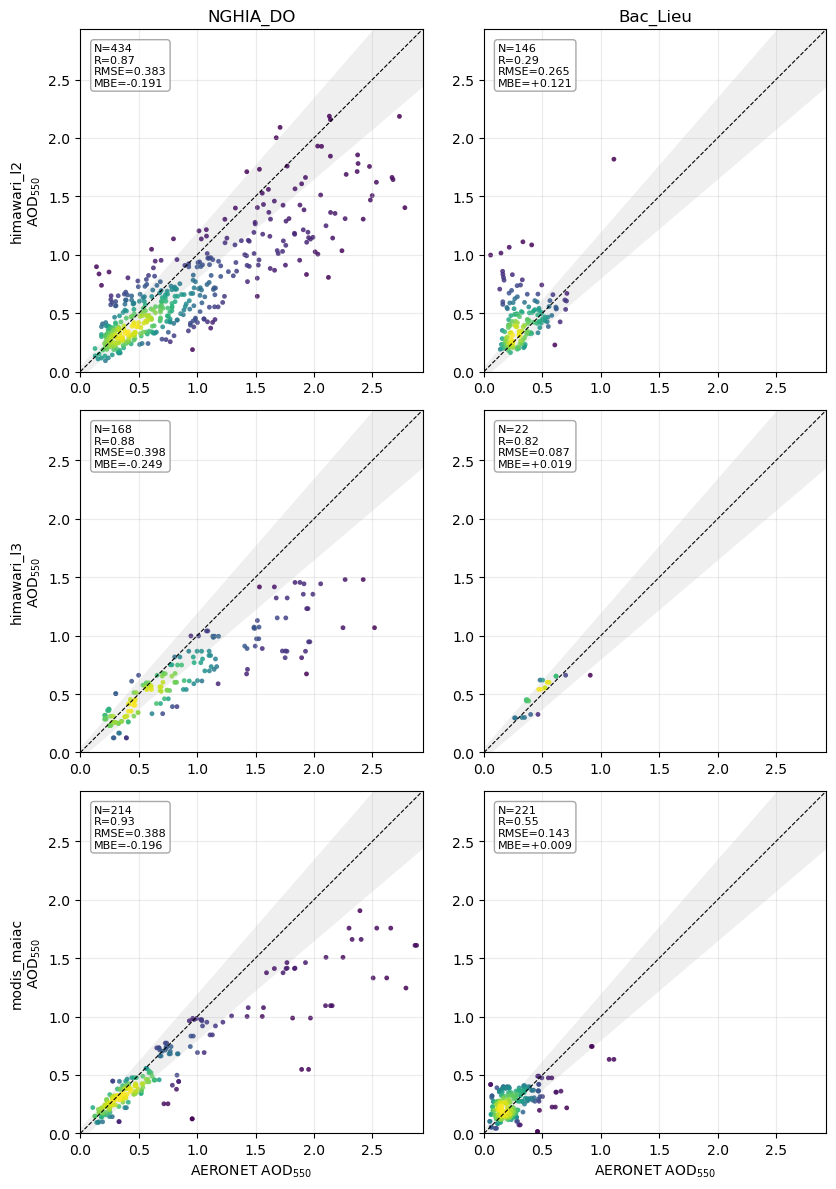

  wrote /home/work1/projects/Air_Quality/AOD_map/stage_a/figures/persensor_aeronet_part1.pdf  (3 sensors)


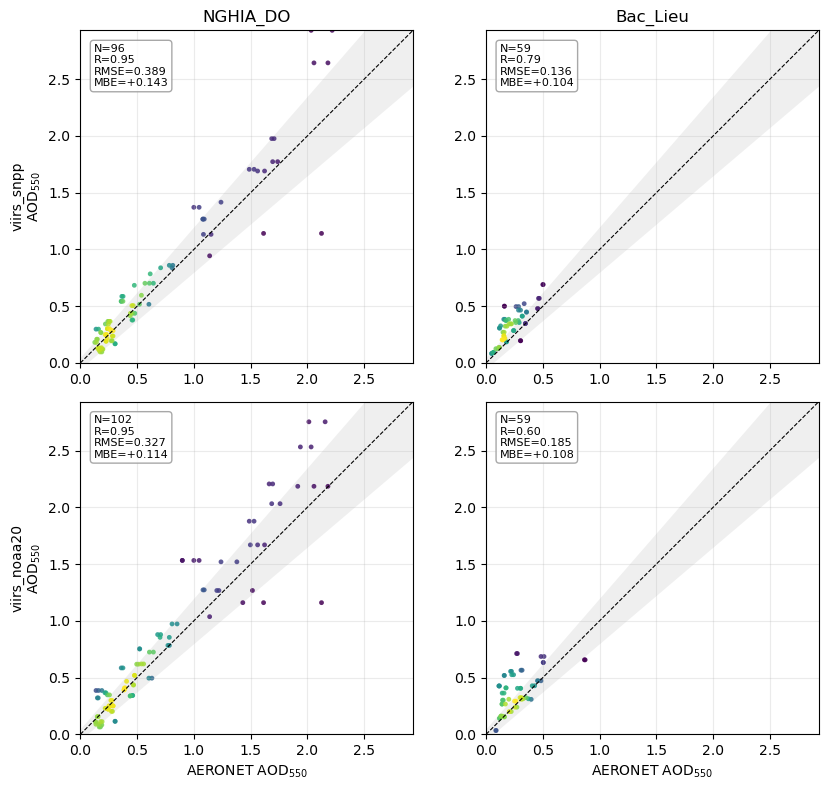

  wrote /home/work1/projects/Air_Quality/AOD_map/stage_a/figures/persensor_aeronet_part2.pdf  (2 sensors)


In [5]:
# Row order (sensors) and column order (stations) are fixed so the grid layout
# stays stable across reruns / future sensors.
STATION_COLS = ['NGHIA_DO', 'Bac_Lieu']

# --- Split the 5×2 grid into two sub-figures so it fits on thesis pages.
# Panels stay the same physical size in both; the LaTeX side stitches them
# into a single "Figure X (cont.)" via \ContinuedFloat.
#
# TODO(you): pick the split that makes the narrative you want. Two natural
# choices are:
#   (a) family split  — GEO + polar-morning first, VIIRS pair second
#   (b) 3+2 balanced  — larger group first so the top page carries the caption
# I'm going with a family-based 3+2 split below; swap as you like.
SENSOR_GROUPS = [
    ['himawari_l2', 'himawari_l3', 'modis_maiac'],   # part 1 (3 rows)
    ['viirs_snpp',  'viirs_noaa20'],                 # part 2 (2 rows)
]

# Where the PDFs land. `../figures` next to the notebook keeps them
# out of `output/` so the pipeline doesn't overwrite them.
FIG_DIR = Path.cwd() / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


def point_density(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Per-point Gaussian-KDE density for the scatter colouring."""
    if x.size < 2:
        return np.zeros_like(x)
    try:
        xy = np.vstack([x, y])
        return stats.gaussian_kde(xy)(xy)
    except (np.linalg.LinAlgError, ValueError):
        return np.zeros_like(x)


def _panel_metrics(sub: pd.DataFrame) -> dict:
    """N, R, RMSE, MBE for one (sensor, station) panel."""
    sat = sub['sat_aod'].to_numpy(dtype=np.float64)
    aer = sub['aeronet_aod'].to_numpy(dtype=np.float64)
    m   = np.isfinite(sat) & np.isfinite(aer)
    sat, aer = sat[m], aer[m]
    n = int(sat.size)
    if n < 2:
        return {'N': n, 'R': np.nan, 'RMSE': np.nan, 'MBE': np.nan}
    return {
        'N':    n,
        'R':    float(np.corrcoef(sat, aer)[0, 1]),
        'RMSE': float(np.sqrt(np.mean((sat - aer) ** 2))),
        'MBE':  float(np.mean(sat - aer)),
    }


def plot_sensor_grid(sensors: list[str], axis_max: float, savepath: Path):
    """Draw one (len(sensors) × 2) density-scatter grid and save as PDF."""
    nrows, ncols = len(sensors), len(STATION_COLS)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows),
                             squeeze=False)

    x_ee = np.linspace(0, axis_max, 200)
    ee   = 0.05 + 0.15 * x_ee

    for i, sensor in enumerate(sensors):
        for j, site in enumerate(STATION_COLS):
            ax  = axes[i, j]
            sub = pairs[(pairs['sensor'] == sensor) & (pairs['site'] == site)]
            aer = sub['aeronet_aod'].to_numpy(dtype=np.float64)
            sat = sub['sat_aod'].to_numpy(dtype=np.float64)
            mask = np.isfinite(aer) & np.isfinite(sat)
            aer, sat = aer[mask], sat[mask]

            ax.fill_between(x_ee, x_ee - ee, x_ee + ee,
                            color='gray', alpha=0.12, lw=0)
            ax.plot([0, axis_max], [0, axis_max], 'k--', lw=0.8)

            if aer.size >= 2:
                dens = point_density(aer, sat)
                order = np.argsort(dens)
                ax.scatter(aer[order], sat[order], c=dens[order],
                           s=12, cmap='viridis', alpha=0.85, lw=0)

            stats_p = _panel_metrics(sub)
            txt = (f"N={stats_p['N']}\n"
                   f"R={stats_p['R']:.2f}\n"
                   f"RMSE={stats_p['RMSE']:.3f}\n"
                   f"MBE={stats_p['MBE']:+.3f}")
            ax.text(0.04, 0.96, txt, transform=ax.transAxes,
                    ha='left', va='top', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3',
                              fc='white', ec='0.6', alpha=0.85))

            ax.set_xlim(0, axis_max)
            ax.set_ylim(0, axis_max)
            ax.set_aspect('equal', adjustable='box')
            ax.grid(alpha=0.25)

            if i == nrows - 1:
                ax.set_xlabel(r'AERONET AOD$_{550}$')
            if j == 0:
                ax.set_ylabel(f"{sensor}\nAOD$_{{550}}$")
            if i == 0:
                ax.set_title(site)

    fig.tight_layout()
    fig.savefig(savepath, bbox_inches='tight')
    plt.show()
    plt.close(fig)


if not pairs.empty:
    # Shared axis limit so the two sub-figures are visually comparable.
    axis_max = float(np.nanpercentile(
        np.r_[pairs['sat_aod'].values, pairs['aeronet_aod'].values], 99.5))
    axis_max = max(axis_max, 1.0)

    for k, group in enumerate(SENSOR_GROUPS, start=1):
        out = FIG_DIR / f'persensor_aeronet_part{k}.pdf'
        plot_sensor_grid(group, axis_max, out)
        print(f'  wrote {out}  ({len(group)} sensors)')


## 5. Optional — export the panel

Useful if the §8 write-up needs the per-sensor table as a CSV / LaTeX.

In [6]:
# from config import OUTPUT_DIR
# out = OUTPUT_DIR / 'validate_persensor_aeronet.csv'
# if not panel.empty:
#     panel.round(4).to_csv(out, index=False)
#     print(f'Wrote {out}')
